In [4]:
# imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# all columns
df = pd.read_csv('../data/ecommerce_sample_clean.csv', parse_dates=["event_time"])

df.tail()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category
341556,2019-10-01 10:22:43,view,1005014,2053013555631882655,electronics.smartphone,Samsung,614.53,530701630,faf3587e-223b-422a-bfdf-6e2c8f6aaceb,electronics
341557,2019-10-01 10:22:43,view,1306569,2053013558920217191,computers.notebook,Acer,1055.11,538432783,4a09e6b3-52c5-4809-8edc-73b211995352,computers
341558,2019-10-01 10:22:43,view,3601126,2053013563810775923,appliances.kitchen.washer,Haier,308.86,554152292,ab54bcb7-6f91-4e02-b108-40ccebf2f02d,appliances
341559,2019-10-01 10:22:43,view,10900328,2053013555069845885,appliances.kitchen.mixer,Dauscher,12.84,529522881,c21547fb-d417-4096-bba1-60582f4732a0,appliances
341560,2019-10-01 10:22:43,view,5701114,2053013553970938175,auto.accessories.player,Prology,25.74,516810731,d7ecd02e-f15f-4f7a-8e43-07e6db9e717d,auto


In [6]:
# EXPLORATORY ANALYSIS
# 1. Event type count (how many carts, purchases and views)
df.groupby('event_type').size().reset_index(name='count')

,event_type,count
0,cart,7567
1,purchase,7644
2,view,326350


In [7]:
# 2. user_id unique counts
count = df.groupby('user_id').size().reset_index(name='size')

count[count["size"] == 1]

,user_id,size
4,332550649,1
5,351866718,1
7,370076704,1
8,374879087,1
12,388419369,1
...,...,...
66697,555583755,1
66698,555583774,1
66700,555583810,1
66702,555583927,1


In [8]:
# 3. unique user_session count
count = df.groupby('user_session').size().reset_index(name='size')

count[count["size"] == 1]

,user_session,size
3,00053790-dcfa-4852-bf10-fa526f14f711,1
4,0005957a-094f-4c99-afd1-448bd7d8139a,1
5,0006852b-f9a2-4d84-b439-acc1f9e6771e,1
9,000c8aaa-d614-433a-9621-a53629f39fd9,1
24,001d92a9-64a1-48eb-871f-61b5bc073c60,1
...,...,...
85704,fff77e7c-ab1a-413d-ba03-93f4e3e18927,1
85707,fff9641e-c11e-4aa3-af98-e4f17e5444c0,1
85710,fffa8b40-4580-4889-8a7c-763e9febda06,1
85711,fffb1f57-6870-4fd4-b5bf-3f362aa2d152,1


In [9]:
# 4. number of unknown categories and unknown brands
df1 = df.groupby('category_code').size().reset_index(name='count')
df2 = df.groupby('brand').size().reset_index(name='count')

print(df1[df1["category_code"] == 'unknown'])
print()
print(df2[df2["brand"] == 'Unknown'])

Empty DataFrame
Columns: [category_code, count]
Index: []

        brand  count
1040  Unknown  26390


In [10]:
# 5. top 10 leading brands
df1 = df.groupby('brand').size().reset_index(name='count')

df1 = df1.loc[df1["brand"] != 'Unknown']

df1.sort_values(by='count', ascending=False).head(10)

,brand,count
886,Samsung,59534
55,Apple,51992
1104,Xiaomi,29725
479,Huawei,13551
3,Acer,4812
611,Lg,4732
606,Lenovo,4575
475,Hp,4163
751,Oppo,4098
157,Bosch,3776


In [11]:
# 6. top 10 leading categories
df1 = df.groupby('category').size().reset_index(name='count')

df1 = df1.loc[df1["category"] != 'unknown']

df1.sort_values(by='count', ascending=False).head(10)

,category,count
7,electronics,191696
2,appliances,59624
4,computers,28663
1,apparel,14431
8,furniture,13352
3,auto,12571
5,construction,9548
9,kids,6380
0,accessories,2703
11,sport,2068


In [12]:
# 7. Price stats

# minimum price
min_price = df['price'].min()

# maximum price
max_price = df['price'].max()

# average price
avg_price = df['price'].mean()

# median price
med_price = df['price'].median()

df_price_stats = pd.DataFrame({
    'min_price': [min_price],
    'max_price': [max_price],
    'avg_price': [avg_price],
    'median_price': [med_price]
})

df_price_stats

,min_price,max_price,avg_price,median_price
0,0.0,2574.07,345.097371,193.03


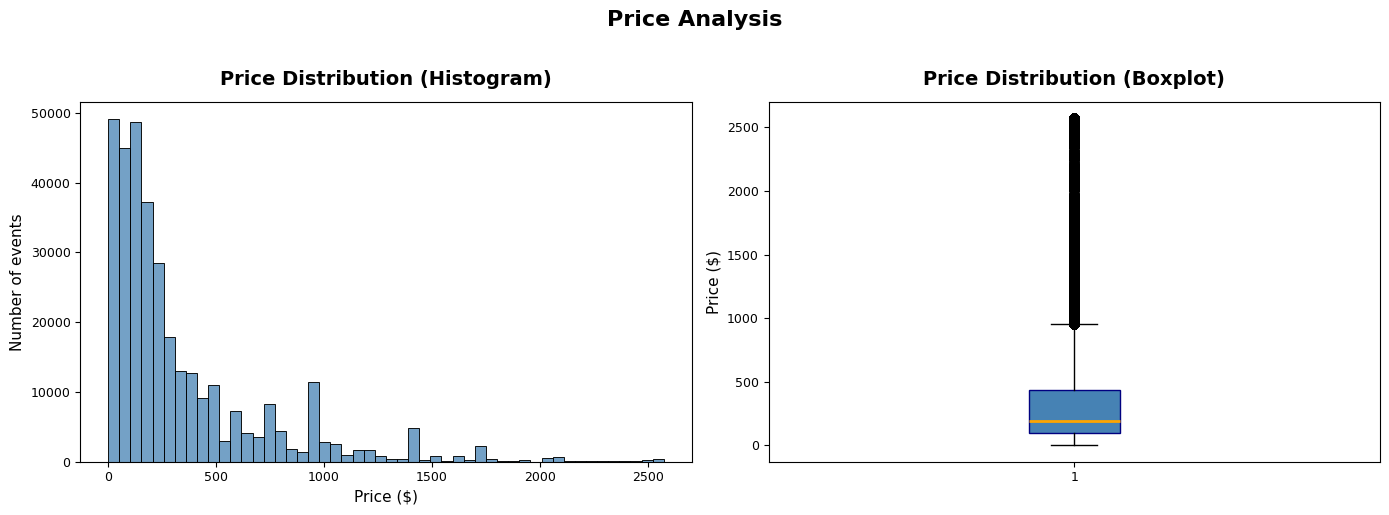

In [13]:
# 8. Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
sns.histplot(
    data=df, 
    x='price',
    bins=50,
    color='steelblue',
    ax=axes[0]
)

axes[0].set_title(
    'Price Distribution (Histogram)',
    fontsize=14,
    fontweight='bold',
    pad=12
)

axes[0].set_xlabel('Price ($)', fontsize=11)
axes[0].set_ylabel('Number of events', fontsize=11)
axes[0].tick_params(labelsize=9)


# boxplot
axes[1].boxplot(
    df['price'], 
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', color='navy'),
    medianprops=dict(color='orange', linewidth=2)
)

axes[1].set_title(
    'Price Distribution (Boxplot)',
    fontsize=14,
    fontweight='bold',
    pad=12
)

axes[1].set_ylabel('Price ($)', fontsize=11)
axes[1].tick_params(labelsize=9)

plt.suptitle('Price Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

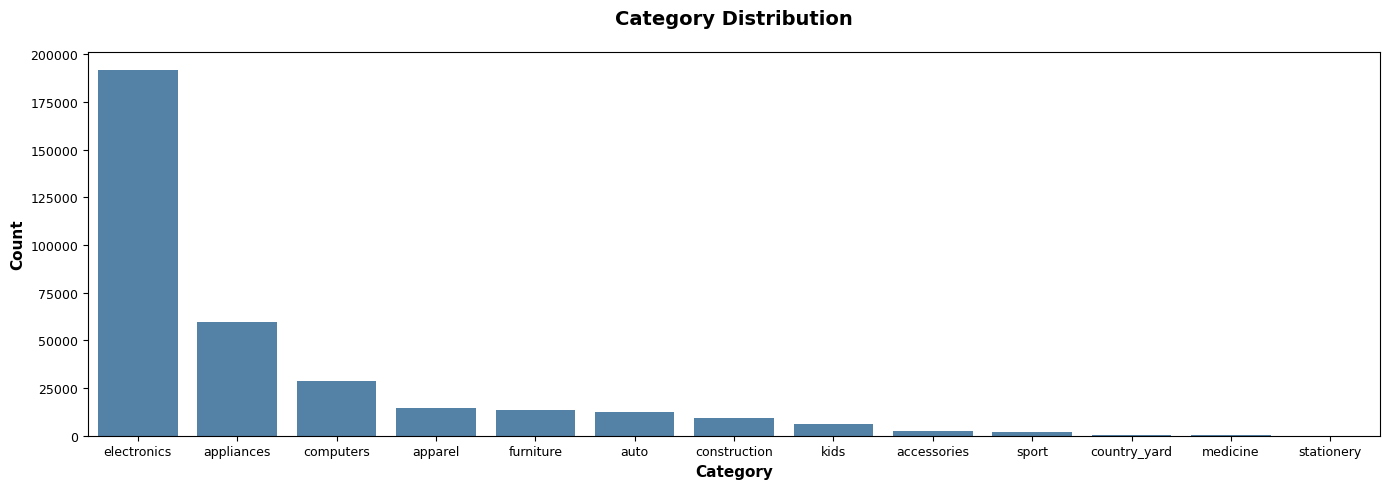

In [16]:
# 9. Category distribution
fig, axes = plt.subplots(figsize=(14, 5))

df_cat = df.groupby('category').size().reset_index(name='count')
df_cat = df_cat.sort_values(by='count', ascending=False)

sns.barplot(
    data=df_cat, 
    x='category', 
    y='count', 
    color='steelblue',
    ax=axes
)

axes.set_title(
    'Category Distribution',
    fontsize=14,
    fontweight='bold',
    pad=20
)

axes.set_xlabel('Category', fontsize=11, fontweight='bold')
axes.set_ylabel('Count', fontsize=11, fontweight='bold')
axes.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

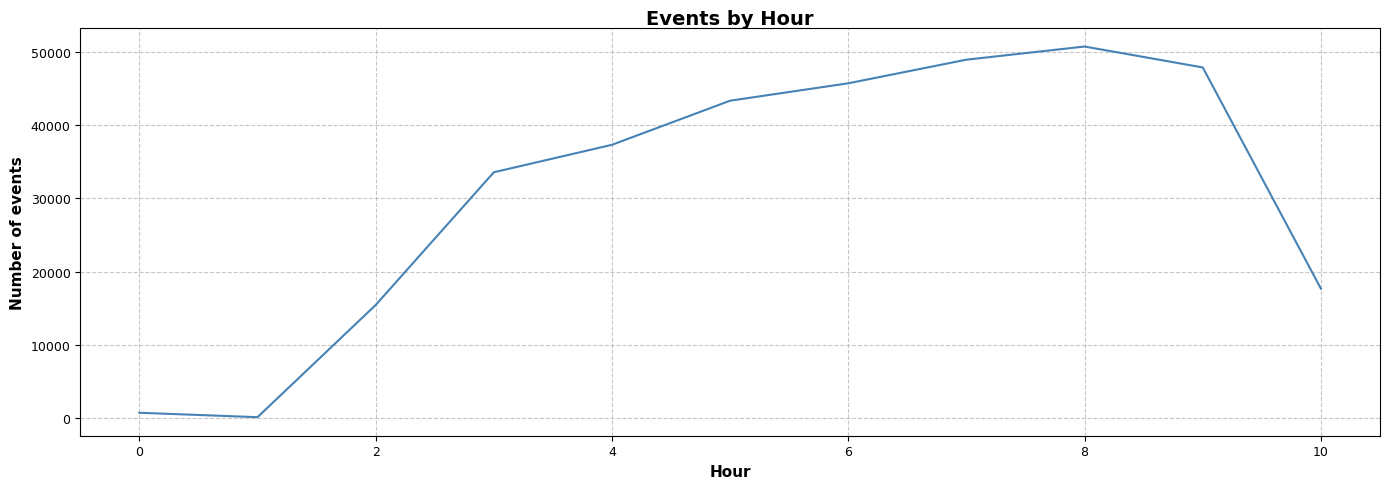

In [15]:
# 10. Time series analysis of events
df['hour'] = df["event_time"].dt.hour

hourly = df.groupby('hour').size().reset_index(name='events')

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=hourly,
    x='hour', y='events',
    color='steelblue',
    ax=ax
)

ax.set_title(
    'Events by Hour',
    fontsize=14,
    fontweight='bold',
    pad=0
)

ax.set_xlabel('Hour', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of events', fontsize=11, fontweight='bold')
ax.tick_params(labelsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()